In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

In [59]:
df = pd.read_csv("geostone_land_dataset.csv")

print(df.columns)
print(df.head())
print(df.shape)

Index(['Plot_ID', 'Point_No', 'Latitude', 'Longitude', 'Shape_Type',
       'Actual_Area_Acre', 'Boundary_Error'],
      dtype='str')
  Plot_ID  Point_No  Latitude  Longitude Shape_Type  Actual_Area_Acre  \
0    P001       1.0   16.7051    74.2431  Rectangle               1.2   
1    P001       2.0   16.7051    74.2441  Rectangle               1.2   
2    P001       3.0   16.7061    74.2441  Rectangle               1.2   
3    P001       4.0   16.7061    74.2431  Rectangle               1.2   
4     NaN       NaN       NaN        NaN        NaN               NaN   

   Boundary_Error  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             NaN  
(49, 7)


In [60]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Plot_ID', 'Point_No', 'Latitude', 'Longitude', 'Shape_Type',
       'Actual_Area_Acre', 'Boundary_Error'],
      dtype='str')


In [61]:
print(df["Plot_ID"].unique())
print("Total plots:", df["Plot_ID"].nunique())

<ArrowStringArray>
['P001',    nan, 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008',
 'P009', 'P010']
Length: 11, dtype: str
Total plots: 10


In [62]:
def convert_to_meters(lat, lon):
    x = lat * 111320
    y = lon * 111320
    return (x, y)

def calculate_area(coords):
    meter_coords = [convert_to_meters(lat, lon) for lat, lon in coords]
    polygon = Polygon(meter_coords)
    return polygon.area / 4046.86   # convert sq meters to acres

In [63]:
df["Plot_ID"] = df["Plot_ID"].astype(str).str.strip()

print(df["Plot_ID"].unique())

<ArrowStringArray>
['P001',    nan, 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008',
 'P009', 'P010']
Length: 11, dtype: str


In [64]:
results = []

for plot_id in df["Plot_ID"].unique():
    plot_data = df[df["Plot_ID"] == plot_id]

    if plot_data.empty:
        continue

    coords = list(zip(
        plot_data["Latitude"],
        plot_data["Longitude"]
    ))

    calculated_area = calculate_area(coords)

    actual_area = plot_data["Actual_Area_Acre"].values[0]

    results.append([
        plot_id,
        actual_area,
        calculated_area
    ])

area_df = pd.DataFrame(
    results,
    columns=[
        "Plot_ID",
        "Actual_Area_Acre",
        "Calculated_Area"
    ]
)

print(area_df)

  Plot_ID  Actual_Area_Acre  Calculated_Area
0    P001              1.20         3.062162
1    P002              0.80         1.714811
2    P003              2.10         5.511892
3    P004              1.50         3.169338
4    P005              0.95         1.347351
5    P006              3.20         9.186487
6    P007              2.40         3.751149
7    P008              4.00        15.310812
8    P009              1.70         2.082270
9    P010              2.90         4.547311


In [65]:
area_df["Error_%"] = abs(
    (area_df["Actual_Area_Acre"] - area_df["Calculated_Area"])
    / area_df["Actual_Area_Acre"]
) * 100

print(area_df)

  Plot_ID  Actual_Area_Acre  Calculated_Area     Error_%
0    P001              1.20         3.062162  155.180197
1    P002              0.80         1.714811  114.351366
2    P003              2.10         5.511892  162.471060
3    P004              1.50         3.169338  111.289203
4    P005              0.95         1.347351   41.826468
5    P006              3.20         9.186487  187.077722
6    P007              2.40         3.751149   56.297871
7    P008              4.00        15.310812  282.770296
8    P009              1.70         2.082270   22.486495
9    P010              2.90         4.547311   56.803832


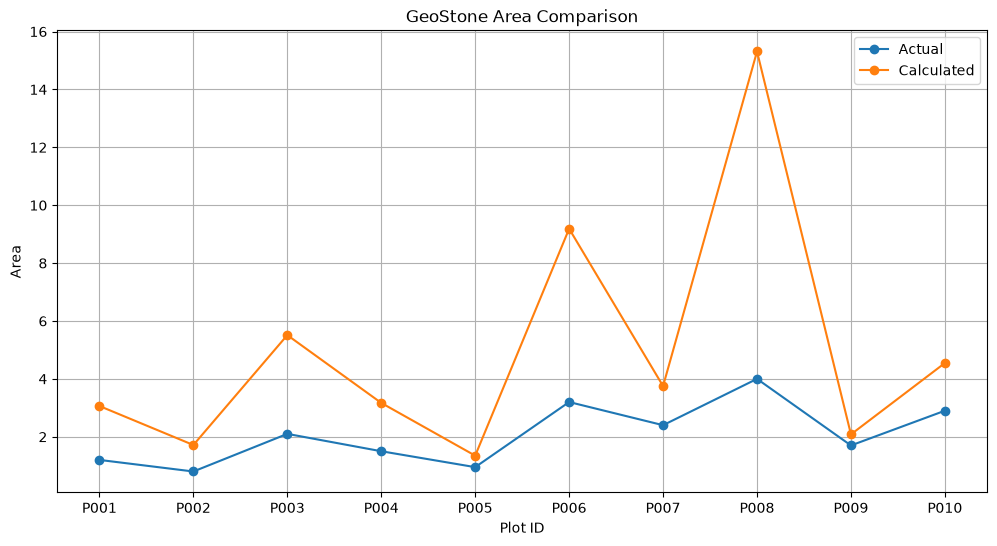

In [66]:
plt.figure(figsize=(12,6))

plt.plot(
    area_df["Plot_ID"],
    area_df["Actual_Area_Acre"],
    marker="o",
    label="Actual"
)

plt.plot(
    area_df["Plot_ID"],
    area_df["Calculated_Area"],
    marker="o",
    label="Calculated"
)

plt.title("GeoStone Area Comparison")
plt.xlabel("Plot ID")
plt.ylabel("Area")
plt.legend()
plt.grid(True)
plt.show()

In [67]:
wrong_points = df[df["Boundary_Error"] == 1]

print(wrong_points)

   Plot_ID  Point_No  Latitude  Longitude Shape_Type  Actual_Area_Acre  \
44    P010       1.0    16.724     74.258  Irregular               2.9   

    Boundary_Error  
44             1.0  


In [68]:
from shapely.geometry import Point

In [69]:
plot_data = df[df["Plot_ID"] == "P001"]

coords = list(zip(
    plot_data["Latitude"],
    plot_data["Longitude"]
))

boundary_polygon = Polygon(coords)

print("Boundary created")

Boundary created


In [70]:
test_point = Point(16.7055, 74.2435)

if boundary_polygon.contains(test_point):
    print("Inside Boundary ✅")
else:
    print("Outside Boundary ❌")

Inside Boundary ✅


In [71]:
test_point = Point(16.7080, 74.2460)

if boundary_polygon.contains(test_point):
    print("Inside Boundary ✅")
else:
    print("Outside Boundary ❌")
    print("ALERT! Boundary Crossed 🚨")

Outside Boundary ❌
ALERT! Boundary Crossed 🚨


In [72]:
def boundary_check(lat, lon, polygon):
    point = Point(lat, lon)

    if polygon.contains(point):
        return "Inside Boundary ✅"
    else:
        return "Outside Boundary 🚨"

In [73]:
result = boundary_check(
    16.7054,
    74.2436,
    boundary_polygon
)

print(result)

Inside Boundary ✅


In [74]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [75]:
import folium

In [76]:
plot_data = df[df["Plot_ID"] == "P001"]

coords = list(zip(
    plot_data["Latitude"],
    plot_data["Longitude"]
))

m = folium.Map(
    location=[coords[0][0], coords[0][1]],
    zoom_start=18
)

print("Map created")

Map created


In [77]:
folium.Polygon(
    locations=coords,
    color="blue",
    fill=True,
    fill_color="green",
    fill_opacity=0.4,
    popup="Plot Boundary"
).add_to(m)

m

In [78]:
for i, point in enumerate(coords):
    folium.Marker(
        location=point,
        popup=f"Point {i+1}"
    ).add_to(m)

m

In [79]:
m.save("plot_map.html")

print("Map saved")

Map saved


In [80]:
shape_data = []

# Clean Plot_ID first
df["Plot_ID"] = df["Plot_ID"].astype(str).str.strip()

for plot_id in df["Plot_ID"].dropna().unique():
    plot_data = df[df["Plot_ID"] == plot_id]

    if plot_data.empty:
        continue

    num_points = len(plot_data)
    area = float(plot_data["Actual_Area_Acre"].values[0])
    boundary_error = plot_data["Boundary_Error"].sum()
    shape_type = plot_data["Shape_Type"].values[0]

    shape_data.append([
        num_points,
        area,
        boundary_error,
        shape_type
    ])

shape_df = pd.DataFrame(
    shape_data,
    columns=[
        "Num_Points",
        "Area",
        "Boundary_Error",
        "Shape_Type"
    ]
)

print(shape_df)

   Num_Points  Area  Boundary_Error Shape_Type
0           4  1.20             0.0  Rectangle
1           3  0.80             0.0   Triangle
2           4  2.10             0.0  Rectangle
3           5  1.50             0.0  Irregular
4           3  0.95             0.0   Triangle
5           4  3.20             0.0  Rectangle
6           5  2.40             0.0  Irregular
7           4  4.00             0.0  Rectangle
8           3  1.70             0.0   Triangle
9           5  2.90             1.0  Irregular


In [81]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

shape_df["Shape_Label"] = encoder.fit_transform(
    shape_df["Shape_Type"]
)

print(shape_df)

   Num_Points  Area  Boundary_Error Shape_Type  Shape_Label
0           4  1.20             0.0  Rectangle            1
1           3  0.80             0.0   Triangle            2
2           4  2.10             0.0  Rectangle            1
3           5  1.50             0.0  Irregular            0
4           3  0.95             0.0   Triangle            2
5           4  3.20             0.0  Rectangle            1
6           5  2.40             0.0  Irregular            0
7           4  4.00             0.0  Rectangle            1
8           3  1.70             0.0   Triangle            2
9           5  2.90             1.0  Irregular            0


In [82]:
X = shape_df[
    ["Num_Points", "Area", "Boundary_Error"]
]

y = shape_df["Shape_Label"]

print(X.head())
print(y.head())

   Num_Points  Area  Boundary_Error
0           4  1.20             0.0
1           3  0.80             0.0
2           4  2.10             0.0
3           5  1.50             0.0
4           3  0.95             0.0
0    1
1    2
2    1
3    0
4    2
Name: Shape_Label, dtype: int64


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8, 3)
(2, 3)


In [84]:
from sklearn.tree import DecisionTreeClassifier

shape_model = DecisionTreeClassifier(
    random_state=42
)

shape_model.fit(X_train, y_train)

print("Shape model trained")

Shape model trained


In [85]:
from sklearn.metrics import accuracy_score

y_pred = shape_model.predict(X_test)

print("Shape Accuracy:", accuracy_score(y_test, y_pred))

Shape Accuracy: 0.5


In [86]:
sample_shape = [[4, 1.5, 0]]

prediction = shape_model.predict(sample_shape)

predicted_shape = encoder.inverse_transform(prediction)

print("Predicted Shape:", predicted_shape[0])

Predicted Shape: Rectangle


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [87]:
gps_data = df.copy()

# Remove rows with missing lat/lon
gps_data = gps_data.dropna(
    subset=["Latitude", "Longitude"]
)

# Convert to numeric
gps_data["Latitude"] = pd.to_numeric(
    gps_data["Latitude"]
)

gps_data["Longitude"] = pd.to_numeric(
    gps_data["Longitude"]
)

# Generate artificial GPS error
gps_data["GPS_Error"] = np.random.uniform(
    0.0001,
    0.0005,
    len(gps_data)
)

# Corrected coordinates
gps_data["Corrected_Latitude"] = (
    gps_data["Latitude"] - gps_data["GPS_Error"]
)

gps_data["Corrected_Longitude"] = (
    gps_data["Longitude"] - gps_data["GPS_Error"]
)

print(gps_data.head())
print(gps_data.isnull().sum())

  Plot_ID  Point_No  Latitude  Longitude Shape_Type  Actual_Area_Acre  \
0    P001       1.0   16.7051    74.2431  Rectangle               1.2   
1    P001       2.0   16.7051    74.2441  Rectangle               1.2   
2    P001       3.0   16.7061    74.2441  Rectangle               1.2   
3    P001       4.0   16.7061    74.2431  Rectangle               1.2   
5    P002       1.0   16.7070    74.2450   Triangle               0.8   

   Boundary_Error  GPS_Error  Corrected_Latitude  Corrected_Longitude  
0             0.0   0.000169           16.704931            74.242931  
1             0.0   0.000226           16.704874            74.243874  
2             0.0   0.000180           16.705920            74.243920  
3             0.0   0.000109           16.705991            74.242991  
5             0.0   0.000323           16.706677            74.244677  
Plot_ID                0
Point_No               0
Latitude               0
Longitude              0
Shape_Type             0
Actu

In [88]:
X = gps_data[
    ["Latitude", "Longitude", "GPS_Error"]
]

y_lat = gps_data["Corrected_Latitude"]
y_lon = gps_data["Corrected_Longitude"]

print(X.head())

   Latitude  Longitude  GPS_Error
0   16.7051    74.2431   0.000169
1   16.7051    74.2441   0.000226
2   16.7061    74.2441   0.000180
3   16.7061    74.2431   0.000109
5   16.7070    74.2450   0.000323


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_lat_train, y_lat_test = train_test_split(
    X, y_lat,
    test_size=0.2,
    random_state=42
)

_, _, y_lon_train, y_lon_test = train_test_split(
    X, y_lon,
    test_size=0.2,
    random_state=42
)

In [90]:
from sklearn.ensemble import RandomForestRegressor

lat_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

lat_model.fit(X_train, y_lat_train)

print("Latitude model trained")

Latitude model trained


In [91]:
lon_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

lon_model.fit(X_train, y_lon_train)

print("Longitude model trained")

Longitude model trained


In [92]:
sample = [[16.7051, 74.2431, 0.0003]]

pred_lat = lat_model.predict(sample)
pred_lon = lon_model.predict(sample)

print("Corrected Latitude:", pred_lat[0])
print("Corrected Longitude:", pred_lon[0])

Corrected Latitude: 16.705928943984727
Corrected Longitude: 74.24394670355136


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
